# One Pipeline for Open-Set Classification

You have training data for 30 classes. At test time, inputs from classes you have never
seen will arrive. The system must classify the known and reject the unknown.

After four notebooks of experiments (Parts 1–4 of this series), one pipeline won. This
notebook builds it from scratch and explains why each piece exists:

1. **Train the classifier so each class becomes a tight, round cluster** in its feature
   space — a margin loss that knows when to stop, on a network that cannot cheat with
   distances.
2. **Score each input by its closeness to the nearest cluster** — one Gaussian per class,
   Mahalanobis distance.
3. **Reject anything farther out than 95% of known-good data ever gets** — a fence read
   off your own data, never off a formula.
4. **Use your 60 collected outliers to measure the result — never to train it.**

Everything runs live below, in about three minutes on CPU, with a worked example at
every stage — including the mistake you must not make, demonstrated rather than
described. This notebook is self-contained and argues from first principles: every
choice is either derived on the page or measured live below. Parts 1–4 of the series
hold the broader experiments behind those choices — optional depth, never a
prerequisite.

In [1]:
import warnings

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.stats import chi2
from scipy.stats import rankdata
from sklearn.covariance import LedoitWolf
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore", message=".*encountered in matmul")
torch.set_num_threads(4)
rng = np.random.default_rng(7)

plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
})


def auroc(s_in, s_out):
    """P(known scores above unknown): 0.5 = useless, 1.0 = perfect."""
    s = np.concatenate([s_in, s_out]); r = rankdata(s)
    n_in, n_out = len(s_in), len(s_out)
    return (r[:n_in].sum() - n_in * (n_in + 1) / 2) / (n_in * n_out)

## 0. The whole pipeline, in words first

**The situation.** You have labeled training data for 30 classes and a classifier
trained on them. In production, most inputs will belong to those classes and deserve a
label. Some will belong to classes that did not exist at training time — those deserve a
refusal, not a confident guess. You also hold 60 examples of such outliers, collected
along the way. The pipeline below turns the classifier you already wanted into a system
that does both jobs, adds nothing to inference cost, and comes with one guarantee you
can state to a stakeholder.

**Training time — once.** The classifier trains as usual, with two additions that change
nothing about how it is used and everything about how trustworthy its inner
representation becomes. A **margin loss** joins the ordinary objective: it pulls
same-class features together and pushes different classes apart, but *stops* pulling
once a pair is close enough — tight class clusters, never crushed ones. And the feature
layers are **spectrally normalized, with residual connections**: each layer's largest
possible stretch is capped at one, and each block only adds a small correction to a copy
of its input, so distances can be neither blown up nor quietly erased on the way
through. The result is a feature space where every class is a compact cluster and where
distance still means what it meant at the input.

**Fitting the detector — seconds, no training.** Push the training set through the
finished encoder and, in its next-to-last layer, fit the simplest density model there
is: one center per class and one shared, gently regularized shape — thirty means and a
single covariance matrix, computed in closed form. That is the entire detector. A new
input's score is its distance to the *nearest* center, measured in the units the shape
defines (the Mahalanobis distance), sign-flipped so that higher always means safer. And
because the logarithm of a Gaussian's density *is* that distance, ranking inputs by it
is ranking them by how probable the training data says they are — which, section 3
argues, is the only question a novelty detector can honestly answer.

**Drawing the fence — one number.** Score a held-out set of known-good inputs the fit
never touched, and take the 5% quantile of their scores: that value is the fence. The
promise — at most about 5% of genuine known-class inputs will ever be rejected — holds
by a symmetry argument rather than an assumption: a future known-good input is
statistically identical to the held-out ones, so its rank among their scores is
uniformly random. No Gaussianity required, no table consulted.

**Inference — every input, microseconds.** Encode, compute thirty distances, keep the
best, compare with the fence. Above it: emit the classifier's label. Below it: emit
*unknown*. Nothing else runs, and no outlier data is consulted — the decision is two
matrix multiplications and a comparison.

**Measurement — where the 60 finally enter.** The fence's false-alarm rate is
guaranteed; its *catch rate* on novelty cannot be, because that depends on what novelty
shows up — something no amount of known-good data can reveal. The 60 collected outliers
are spent on exactly this: count how many the fence catches, wrap the count in a
binomial interval, report the interval. They are never used for training or tuning — a
detector fitted to 60 examples memorizes the few kinds of novelty you have met and
misses the next kind, a failure this notebook demonstrates live rather than asserts.

**What can go wrong, and where you would see it.** A known input given the wrong label
is an ordinary classification error — the accuracy number's business; the fence neither
causes nor cures it. Novelty that closely resembles a known class can slip past the
fence — that is the measured catch rate, and the honest hard case of the whole problem.
And after any retrain, the detector and the fence are stale by construction: refit both
(seconds) and re-measure, watching two free health checks on the feature space — cluster
tightness and covariance conditioning — that warn when the encoder itself has degraded.

### The same pipeline, in equations

**The training objective**, minimized jointly over encoder and head with Adam:

$$
\mathcal{L}
\;=\;
\underbrace{\mathrm{CE}\big(\mathrm{softmax}(W_{\text{head}}\, z(x) + b_{\text{head}}),\; y\big)}_{\text{classify}}
\;+\;
\underbrace{\operatorname*{mean}_{y_i = y_j}\big[\lVert \hat z_i - \hat z_j\rVert^2 - 0.4\big]_+
\;+\;
\operatorname*{mean}_{y_i \ne y_j}\big[1.2 - \lVert \hat z_i - \hat z_j\rVert^2\big]_+}_{\text{margin loss: pull until close enough, push until far enough}}
$$

where $z(x)$ is the encoder's feature vector, $\hat z = z / \lVert z \rVert$
(normalization used inside the margin term only), the pair-means run over each training
batch with self-pairs excluded, and $[\,\cdot\,]_+ = \max(0, \cdot)$ is the hinge that
switches each force off at its margin — attraction stops at squared distance $0.4$,
repulsion stops at $1.2$.

**The encoder, layer by layer**, with spectral normalization marked exactly where it is
applied ($\bar W$ = normalized weight, $W$ = free weight):

$$
h_0 = \mathrm{ReLU}(\bar W_{\text{in}}\, x + b_{\text{in}}),
\qquad
h_k = h_{k-1} + 0.95 \cdot g_k(h_{k-1}), \quad k = 1, 2,
$$

$$
g_k(h) = \bar W_{k,2}\, \mathrm{ReLU}(\bar W_{k,1}\, h + b_{k,1}) + b_{k,2},
\qquad
z(x) = h_2 \in \mathbb{R}^{64}.
$$

Five weight matrices are normalized — the input projection and both linears in each of
the two residual blocks; the classification head $W_{\text{head}}$ is deliberately left
free (it draws boundaries; it does not shape the space the detector reads).

**Spectral normalization itself.** Every marked weight is used as

$$
\bar W = \frac{W}{\sigma_{\max}(W)},
\qquad
\sigma_{\max}(W) = \max_{v \ne 0} \frac{\lVert W v \rVert}{\lVert v \rVert},
$$

the largest singular value — the layer's largest possible stretch — tracked during
training by one power-iteration step per forward pass,
$u \leftarrow \tfrac{Wv}{\lVert Wv \rVert}$,
$v \leftarrow \tfrac{W^\top u}{\lVert W^\top u \rVert}$,
$\sigma_{\max} \approx u^\top W v$. Biases are untouched: they shift space, never
stretch it.

**The detector**, fitted in closed form on the training features:

$$
\mu_c = \operatorname*{mean}_{y_i = c} z_i,
\qquad
\hat\Sigma = (1 - \lambda)\, \Sigma_{\text{pooled}}
+ \lambda\, \tfrac{\operatorname{tr} \Sigma_{\text{pooled}}}{64}\, I,
\qquad
s(x) = -\min_c\; (z - \mu_c)^\top \hat\Sigma^{-1} (z - \mu_c),
$$

with $\Sigma_{\text{pooled}}$ the covariance of the class-centered training features and
the shrinkage weight $\lambda$ chosen analytically (Ledoit–Wolf).

**The fence and the decision rule:**

$$
\tau = \mathrm{Quantile}_{5\%}\big(\{\, s(x) : x \in \text{held-out known-good} \,\}\big),
\qquad
F(x) =
\begin{cases}
\arg\max_c \big(W_{\text{head}}\, z(x) + b_{\text{head}}\big)_c & s(x) \ge \tau \\[3pt]
\textsf{reject as unknown} & s(x) < \tau .
\end{cases}
$$

Every symbol above appears in the code below, with the same constants — the equations
*are* the program.

That is the whole system. The rest of the notebook builds each piece from first
principles, with a picture at every step. The same map, compressed and indexed to its
sections:

1. **The encoder** — your classifier, trained once with two extra ingredients (a margin
   loss and spectral normalization) so that its feature space is worth trusting. §4.
2. **The detector** — thirty class means and one shared covariance, *fitted* (not
   trained) on the encoder's features in seconds. §3 and §7.
3. **The fence** — one number: the score below which 95% of held-out known-good inputs
   never fall. §5.
4. **Inference** — encode, score, compare: a label, or a rejection. No outlier data
   appears anywhere above this line. §7.
5. **The 60 collected outliers** — deliberately *outside* the pipeline: they measure it,
   with an honest interval, and never shape it. §6.

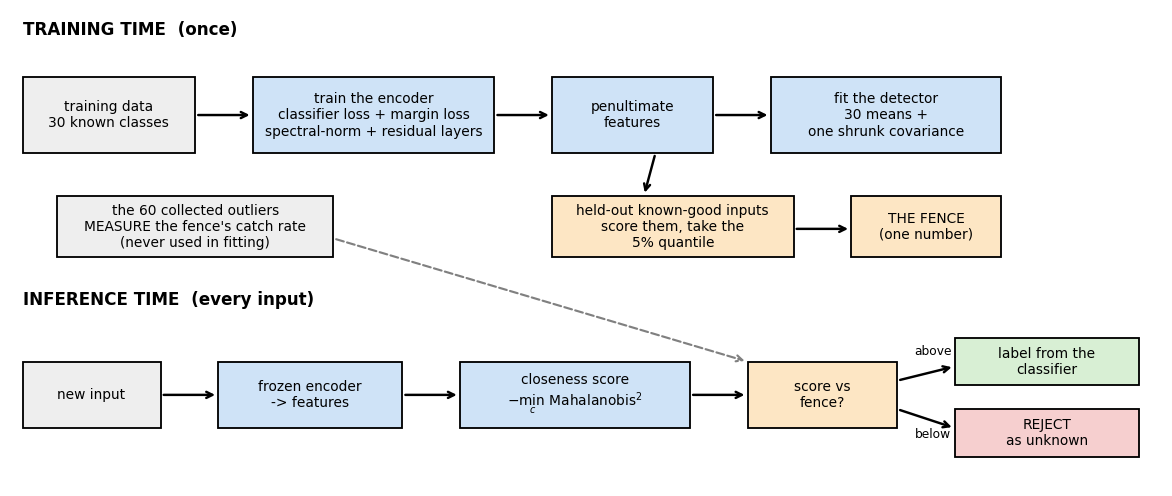

Everything above the fence's arrow is fitted from known-good data alone.
The 60 outliers touch nothing; they only grade the result.


In [2]:
# --- The pipeline, as a diagram ----------------------------------------------------
fig, ax = plt.subplots(figsize=(13.5, 5.6))
ax.axis("off"); ax.set_xlim(0, 100); ax.set_ylim(0, 100)

def box(x, y, w, h, text, fc, fontsize=9):
    ax.add_patch(plt.Rectangle((x, y), w, h, fc=fc, ec="black", lw=1.2, zorder=2))
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center",
            fontsize=fontsize, zorder=3)

def arrow(x1, y1, x2, y2, **kw):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", lw=1.6, **kw))

BLUE, ORANGE, GREEN, RED, GRAY = "#cfe3f7", "#fde6c4", "#d8efd4", "#f6cfcf", "#eeeeee"

ax.text(1, 95, "TRAINING TIME  (once)", fontsize=11, weight="bold")
box(1, 70, 15, 16, "training data\n30 known classes", GRAY)
box(21, 70, 21, 16, "train the encoder\nclassifier loss + margin loss\nspectral-norm + residual layers", BLUE)
box(47, 70, 14, 16, "penultimate\nfeatures", BLUE)
box(66, 70, 20, 16, "fit the detector\n30 means +\none shrunk covariance", BLUE)
arrow(16, 78, 21, 78); arrow(42, 78, 47, 78); arrow(61, 78, 66, 78)
box(47, 48, 21, 13, "held-out known-good inputs\nscore them, take the\n5% quantile", ORANGE)
box(73, 48, 13, 13, "THE FENCE\n(one number)", ORANGE)
arrow(56, 70, 55, 61); arrow(68, 54, 73, 54)

ax.text(1, 38, "INFERENCE TIME  (every input)", fontsize=11, weight="bold")
box(1, 12, 12, 14, "new input", GRAY)
box(18, 12, 16, 14, "frozen encoder\n-> features", BLUE)
box(39, 12, 20, 14, "closeness score\n$-\\min_c$ Mahalanobis$^2$", BLUE)
box(64, 12, 13, 14, "score vs\nfence?", ORANGE)
box(82, 21, 16, 10, "label from the\nclassifier", GREEN)
box(82, 6, 16, 10, "REJECT\nas unknown", RED)
arrow(13, 19, 18, 19); arrow(34, 19, 39, 19); arrow(59, 19, 64, 19)
arrow(77, 22, 82, 25); arrow(77, 16, 82, 12)
ax.text(78.5, 27.5, "above", fontsize=8); ax.text(78.5, 10, "below", fontsize=8)

box(4, 48, 24, 13, "the 60 collected outliers\nMEASURE the fence's catch rate\n(never used in fitting)", GRAY)
ax.annotate("", xy=(64, 26), xytext=(28, 52),
            arrowprops=dict(arrowstyle="->", lw=1.4, ls="--", color="gray"))
plt.show()
print("Everything above the fence's arrow is fitted from known-good data alone.")
print("The 60 outliers touch nothing; they only grade the result.")

## 1. The problem, drawn

Three known classes. New inputs arrive. Some belong; some come from a class that did not
exist at training time. Nothing about an input announces which kind it is.

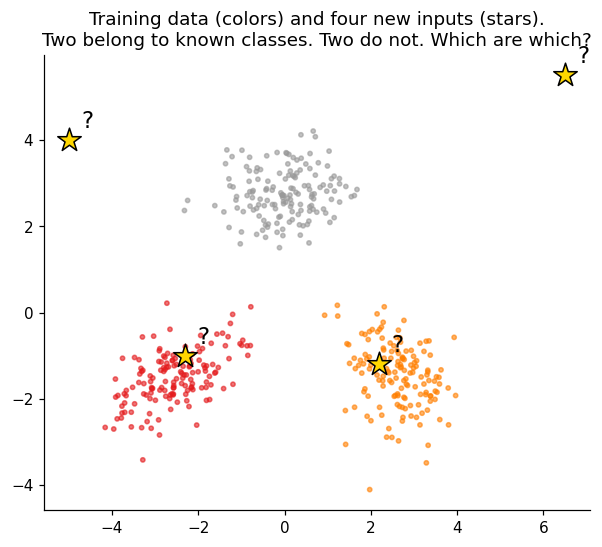

In [3]:
toy_rng = np.random.default_rng(3)
toy_means = np.array([[-2.5, -1.5], [2.5, -1.5], [0.0, 2.8]])
toy_covs = np.array([[[0.55, 0.2], [0.2, 0.35]], [[0.45, -0.15], [-0.15, 0.55]],
                     [[0.6, 0.0], [0.0, 0.3]]])
X_toy = np.vstack([toy_rng.multivariate_normal(m, C_, 150)
                   for m, C_ in zip(toy_means, toy_covs)])
y_toy = np.repeat(np.arange(3), 150)
X_new = np.array([[6.5, 5.5], [-5.0, 4.0], [-2.3, -1.0], [2.2, -1.2]])

fig, ax = plt.subplots(figsize=(6.4, 5.4))
ax.scatter(*X_toy.T, c=y_toy, cmap="Set1", s=8, alpha=0.6)
ax.scatter(*X_new.T, marker="*", s=260, c="gold", edgecolors="black", zorder=5)
for p in X_new:
    ax.annotate("?", p, textcoords="offset points", xytext=(8, 8), fontsize=15)
ax.set_title("Training data (colors) and four new inputs (stars).\n"
             "Two belong to known classes. Two do not. Which are which?")
ax.set_aspect("equal"); ax.grid(False)
plt.show()

## 2. Why the classifier's confidence cannot answer

A softmax classifier answers one question: *which of the known classes fits best?* It has
no way to say "none of them" — its probabilities must sum to 1 across the known classes,
no matter what comes in.

Worse, far from the data its confidence is *guaranteed* to be high, and the reason is
three lines long. Each class's raw score is a linear function of the input. Walk away
from the data in any fixed direction: one class's linear score grows faster than the
rest, the gap widens without limit, and the softmax of a widening gap goes to 1. So
confidence measures distance to the nearest **decision boundary**, not to the **data** —
and far away there are no boundaries left, only the inside of one class's territory:

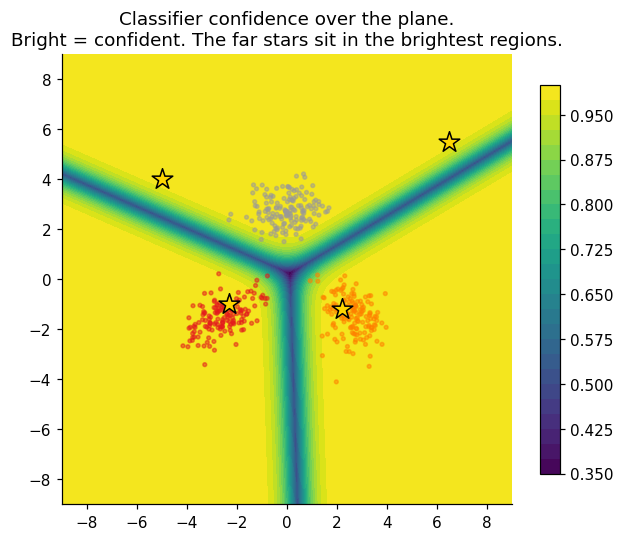

The two genuinely novel inputs get near-perfect confidence.
Confidence cannot detect novelty. It was never asked to.


In [4]:
clf = LogisticRegression(max_iter=1000).fit(X_toy, y_toy)
xs = np.linspace(-9, 9, 300)
XX, YY = np.meshgrid(xs, xs)
GRID = np.column_stack([XX.ravel(), YY.ravel()])

fig, ax = plt.subplots(figsize=(6.6, 5.4))
im = ax.contourf(XX, YY, clf.predict_proba(GRID).max(1).reshape(XX.shape),
                 levels=30, cmap="viridis")
ax.scatter(*X_toy.T, c=y_toy, cmap="Set1", s=6, alpha=0.5)
ax.scatter(*X_new.T, marker="*", s=200, c="gold", edgecolors="black", zorder=5)
fig.colorbar(im, ax=ax, shrink=0.85)
ax.set_title("Classifier confidence over the plane.\n"
             "Bright = confident. The far stars sit in the brightest regions.")
ax.set_aspect("equal"); ax.grid(False)
plt.show()
print("The two genuinely novel inputs get near-perfect confidence.")
print("Confidence cannot detect novelty. It was never asked to.")

## 3. The fix: measure distance to the data

Flip the question. Not *which class fits best* — *does anything fit at all?*

Why is that the right question, and not just a different one? Deciding "does this input
belong?" is a hypothesis test, and the best possible test — the one that catches the most
novelty for any fixed rate of false alarms — compares how *probable* the input is under
the training data against how probable it is under the alternatives. We know nothing
about the alternatives, so the only usable half of that comparison survives: **flag
inputs where the training data's probability is low.** Every good detector is a
probability-of-the-data estimate in some disguise; ours will simply wear the thinnest
disguise available.

The simplest honest model of that probability: each class is a Gaussian cloud, described
by a center and a shape. Take the logarithm of a Gaussian's density and, up to a
constant, out falls a *distance* — the **Mahalanobis distance**:

$$
d_c(x) = \sqrt{(x - \mu_c)^\top \Sigma^{-1} (x - \mu_c)}
$$

In words: *how many typical class-widths separate $x$ from the center of class $c$* — a
step along a direction the class varies a lot in counts for little; a step along a tight
direction counts for a lot. Because distance is just negative log-probability in
disguise, ranking inputs by distance *is* ranking them by how probable the training data
says they are — the opening argument of this section, made concrete. The score for an input is
**minus** its squared distance to the **nearest** center: high means it sits inside some
class, low means it sits in no-man's-land. One sign convention, chosen once, used
everywhere — *higher = safer*.

Two estimation choices, each with a one-line reason. The shape $\Sigma$ is **shared**,
pooled across all classes: a shape has thousands of numbers, each class has few samples,
and pooling multiplies the effective sample size thirty-fold. And the pooled estimate is
**shrunk** — blended slightly toward a plain sphere — because with limited data the
widest and narrowest directions of a fitted shape are always exaggerated, and the fit
must be *inverted*; the Ledoit–Wolf recipe picks the blend automatically.

Two panels: the model we fit, and the closeness landscape it produces.

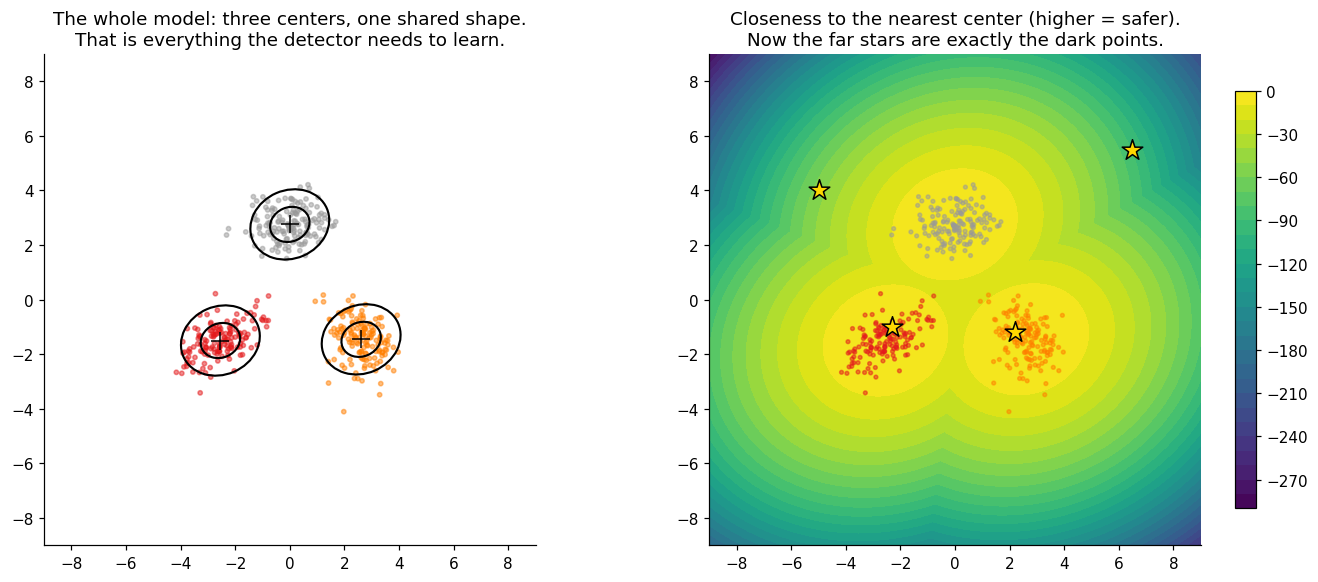

In [5]:
from matplotlib.patches import Ellipse

mus = np.stack([X_toy[y_toy == c].mean(0) for c in range(3)])
resid = X_toy - mus[y_toy]
Sigma = resid.T @ resid / (len(X_toy) - 3)
prec = np.linalg.inv(Sigma)

def maha_score(P):
    d2 = np.stack([np.einsum("nd,dk,nk->n", P - m, prec, P - m) for m in mus], 1)
    return -d2.min(1)                    # higher = closer to some class = safer

fig, axes = plt.subplots(1, 2, figsize=(13, 5.4))

ax = axes[0]
ax.scatter(*X_toy.T, c=y_toy, cmap="Set1", s=8, alpha=0.5)
vals, vecs = np.linalg.eigh(Sigma)
angle = np.degrees(np.arctan2(vecs[1, -1], vecs[0, -1]))
for m in mus:
    for k in (1, 2):
        ax.add_patch(Ellipse(m, 2 * k * np.sqrt(vals[-1]), 2 * k * np.sqrt(vals[0]),
                             angle=angle, fill=False, color="black", lw=1.4))
    ax.plot(*m, marker="+", ms=12, c="black")
ax.set_title("The whole model: three centers, one shared shape.\n"
             "That is everything the detector needs to learn.")
ax.set_aspect("equal"); ax.grid(False); ax.set_xlim(-9, 9); ax.set_ylim(-9, 9)

ax = axes[1]
im = ax.contourf(XX, YY, maha_score(GRID).reshape(XX.shape), levels=30, cmap="viridis")
ax.scatter(*X_toy.T, c=y_toy, cmap="Set1", s=6, alpha=0.5)
ax.scatter(*X_new.T, marker="*", s=200, c="gold", edgecolors="black", zorder=5)
fig.colorbar(im, ax=ax, shrink=0.85)
ax.set_title("Closeness to the nearest center (higher = safer).\n"
             "Now the far stars are exactly the dark points.")
ax.set_aspect("equal"); ax.grid(False)
plt.tight_layout(); plt.show()

Compare the two landscapes. Confidence (section 2) was bright everywhere except thin
bands. Distance is bright only **where the data is** — and the same two stars the
classifier trusted most are now the most suspicious points in the frame. That single
contrast is the whole idea; the rest of this notebook is making it work in high
dimensions.

## 4. Real inputs are not 2-D: score in the classifier's feature space

Real inputs live in many dimensions and their classes are not Gaussian clouds there. But
the classifier's next-to-last layer already maps every input to a vector arranged for
separating the classes — and there is a principled reason to expect *cluster-shaped*
arrangement, not just separable: the network's final step is a linear vote, so by the
time features reach it, training has pulled each class into territory a flat boundary
can cut off. Compact, convex-ish territory is exactly what a Gaussian describes. That is
where we fit them.

Which raises the real question: *is that space any good?* Ordinary training gives classes
no reason to be tight, round, or honestly spaced — it only asks them to be separable. Two
small changes to training fix this, and they are the only changes the pipeline makes:

- **A margin loss**, added to the usual one. Pull same-class features together and push
  different-class features apart — but **stop at a margin**. The stopping is the point:
  Part 2 tested three well-known losses that never stop pulling (SupCon without views,
  center loss, CIDER), and every one crushed its classes into shapes too degenerate to
  fit a Gaussian to. Attraction needs a brake.
- **Spectral normalization** on the encoder layers, with residual connections. The
  normalization caps how much any layer can *stretch* distances. The residual connections
  supply the other half: each block adds a small, capped correction to a copy of its
  input, and a correction that weak can never cancel the copy — so the blocks cannot
  *squash* distances away either. Together they keep the map honest: the encoder cannot
  make a novel region look familiar by collapsing it onto the training data.

Same classifier, same inference cost, about fifteen extra lines of training code. We call
the result the **sn_margin encoder**. Two health checks appear below, so here is what
they mean: **tightness** is the average spread inside a class divided by the average
distance between class centers — lower means rounder, better-separated clusters. The
**condition number** is how many times wider the covariance's widest direction is than
its narrowest — the Gaussian fit must invert this matrix, and huge values mean the
inversion runs on numerical luck. Detection quality is reported as **AUROC**: the
probability that a randomly chosen known-good input outscores a randomly chosen
unknown — 0.5 is a coin flip, 1.0 is perfect separation.

### What spectral normalization actually is

Strip a layer of its activation and a matrix remains — and a matrix does exactly one
thing to space: it maps the unit circle to an ellipse. The ellipse's longest axis is the
layer's **largest possible stretch**; that length is called the spectral norm. Spectral
normalization simply divides the weights by it, every training step, so the longest axis
becomes exactly 1: **no direction of input change can grow when passing through the
layer**. (The number is found almost for free by power iteration — one extra
matrix-vector product per forward pass.)

The cap is only half a guarantee. It stops *stretching*, not *squashing* — a normalized
layer may still flatten some direction to almost nothing, and a flattened direction is
one the detector goes blind in. The **residual connection** supplies the other half: each
block adds a small, capped correction to a copy of its input, and a correction that weak
can never cancel the copy. Two inputs a distance $\lVert \Delta \rVert$ apart obey

$$
(1 - 0.95)\,\lVert \Delta \rVert
\;\le\; \lVert \text{block}(h_1) - \text{block}(h_2) \rVert \;\le\;
(1 + 0.95)\,\lVert \Delta \rVert :
$$

their separation can be neither erased nor blown up. Distance survives every block, in
both directions, to within known factors. (The companion notebook *Spectral
Normalization, Drawn* derives every bound and its fine print.) Here is the whole idea in
one picture — then we train both encoders and look.

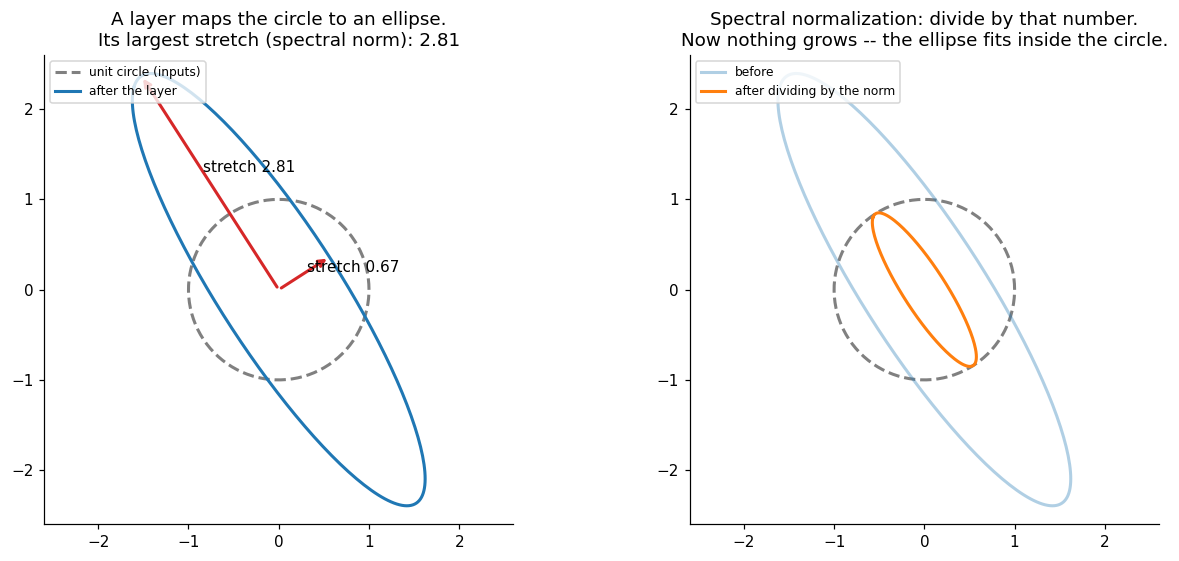

In [6]:
# --- Spectral normalization, in one picture ----------------------------------------
torch.manual_seed(4)
Wm = torch.randn(2, 2)
Um, Sm, Vtm = torch.linalg.svd(Wm)
Wm, Um, Sm = Wm.numpy(), Um.numpy(), Sm.numpy()

theta = np.linspace(0, 2 * np.pi, 200)
circle = np.stack([np.cos(theta), np.sin(theta)])
ellipse = Wm @ circle

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
ax = axes[0]
ax.plot(*circle, lw=2, c="gray", ls="--", label="unit circle (inputs)")
ax.plot(*ellipse, lw=2, c="tab:blue", label="after the layer")
for i in range(2):
    ax.annotate("", xy=Sm[i] * Um[:, i], xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color="tab:red", lw=2))
    ax.annotate(f"stretch {Sm[i]:.2f}", Sm[i] * Um[:, i] * 0.55, fontsize=10)
ax.set_title("A layer maps the circle to an ellipse.\n"
             f"Its largest stretch (spectral norm): {Sm[0]:.2f}")
ax.legend(loc="upper left", fontsize=8)

ax = axes[1]
ax.plot(*circle, lw=2, c="gray", ls="--")
ax.plot(*ellipse, lw=2, c="tab:blue", alpha=0.35, label="before")
ax.plot(*(ellipse / Sm[0]), lw=2, c="tab:orange", label="after dividing by the norm")
ax.set_title("Spectral normalization: divide by that number.\n"
             "Now nothing grows -- the ellipse fits inside the circle.")
ax.legend(loc="upper left", fontsize=8)
for ax in axes:
    ax.set_aspect("equal"); ax.grid(False)
    ax.set_xlim(-2.6, 2.6); ax.set_ylim(-2.6, 2.6)
plt.tight_layout(); plt.show()

In [7]:
# --- A 30-class problem shaped like the real one -----------------------------------
# Classes live in a latent space and reach us through a fixed nonlinear map, so raw
# inputs are NOT Gaussian per class -- the encoder has to earn its feature space.
LATENT_D, OBS_D, C = 8, 64, 30

means_known = rng.normal(size=(C, LATENT_D)) * 1.6
means_near = rng.normal(size=(5, LATENT_D)) * 1.6            # unknown, similar scale
means_far = rng.normal(size=(3, LATENT_D)) * 3.2             # unknown, remote
scales = rng.uniform(0.7, 1.1, size=C + 8)
A_dec = rng.normal(size=(LATENT_D, OBS_D)) / np.sqrt(LATENT_D)
W1_dec = rng.normal(size=(LATENT_D, 32)) * (1.5 / np.sqrt(LATENT_D))
W2_dec = rng.normal(size=(32, OBS_D)) / np.sqrt(32)

def sample_class(mean, scale, n):
    z = mean + rng.normal(size=(n, LATENT_D)) * scale
    x = z @ A_dec + 0.7 * np.tanh(z @ W1_dec) @ W2_dec
    return (x + 0.05 * rng.normal(size=(n, OBS_D))).astype(np.float32)

def id_split(n_per):
    X = np.vstack([sample_class(m, s, n_per) for m, s in zip(means_known, scales[:C])])
    return X, np.repeat(np.arange(C), n_per)

X_train, y_train = id_split(200)
X_val, y_val = id_split(100)                  # held out: the fence is set here
X_test, y_test = id_split(80)
X_near = np.vstack([sample_class(means_near[i], scales[C + i], 150) for i in range(5)])
X_far = np.vstack([sample_class(means_far[i], scales[C + 5 + i], 150) for i in range(3)])
print(f"train {X_train.shape}, val {X_val.shape}, test {X_test.shape}, "
      f"near-unknown {X_near.shape}, far-unknown {X_far.shape}")

train (6000, 64), val (3000, 64), test (2400, 64), near-unknown (750, 64), far-unknown (450, 64)


In [8]:
# --- Two encoders: plain, and sn_margin --------------------------------------------
class PlainNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.f1, self.f2 = nn.Linear(OBS_D, 128), nn.Linear(128, 64)
        self.head = nn.Linear(64, C)
    def forward(self, x):
        z = F.relu(self.f2(F.relu(self.f1(x))))
        return z, self.head(z)


class SNMarginNet(nn.Module):
    """Spectral-normalized residual encoder. The margin loss is added in training."""
    def __init__(self, width=64, blocks=2, coef=0.95):
        super().__init__()
        SN = nn.utils.parametrizations.spectral_norm
        self.inp = SN(nn.Linear(OBS_D, width))
        self.blocks = nn.ModuleList([
            nn.ModuleList([SN(nn.Linear(width, width)), SN(nn.Linear(width, width))])
            for _ in range(blocks)])
        self.coef = coef
        self.head = nn.Linear(width, C)
    def forward(self, x):
        h = F.relu(self.inp(x))
        for a, b in self.blocks:
            h = h + self.coef * b(F.relu(a(h)))
        return h, self.head(h)


def margin_loss(z, y, m_pos=0.4, m_neg=1.2):
    """Pull same-class pairs inside m_pos, push different-class pairs beyond m_neg.
    The hinges switch the forces OFF once the margins are met -- the brake."""
    zn = F.normalize(z, dim=1)
    d2 = torch.cdist(zn, zn).pow(2)
    same = (y[:, None] == y[None, :]).float()
    eye = torch.eye(len(y))
    pos = ((d2 - m_pos).clamp(min=0) * same * (1 - eye)).sum() / ((same - eye).sum() + 1e-9)
    neg = ((m_neg - d2).clamp(min=0) * (1 - same)).sum() / ((1 - same).sum() + 1e-9)
    return pos + neg


def train_encoder(kind, seed, epochs=120, batch=256, lr=1e-3):
    torch.manual_seed(seed)
    model = SNMarginNet() if kind == "sn_margin" else PlainNet()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    Xt, yt = torch.from_numpy(X_train), torch.from_numpy(y_train)
    for _ in range(epochs):
        perm = torch.randperm(len(Xt))
        for i in range(0, len(Xt), batch):
            z, logits = model(Xt[perm[i:i + batch]])
            loss = F.cross_entropy(logits, yt[perm[i:i + batch]])
            if kind == "sn_margin":
                loss = loss + margin_loss(z, yt[perm[i:i + batch]])
            opt.zero_grad(); loss.backward(); opt.step()
    model.eval()
    return model


def features(model, X):
    with torch.no_grad():
        z, logits = model(torch.from_numpy(X))
    return z.numpy(), logits.numpy()


def fit_maha(Ztr, ytr):
    """Class centers + one pooled, shrunk covariance. The entire detector."""
    mu = np.stack([Ztr[ytr == c].mean(0) for c in range(C)])
    prec = LedoitWolf().fit(Ztr - mu[ytr]).precision_
    def score(Z):
        d2 = np.stack([np.einsum("nd,dk,nk->n", Z - m, prec, Z - m) for m in mu], 1)
        return -d2.min(1)
    return score

# Three seeds each, so the comparison is not a coin flip.
MODELS = {}
for kind in ("plain", "sn_margin"):
    accs, nears, fars, tights, conds = [], [], [], [], []
    for seed in range(3):
        model = train_encoder(kind, seed)
        Ztr, _ = features(model, X_train)
        Zte, Lte = features(model, X_test)
        sc = fit_maha(Ztr, y_train)
        accs.append((Lte.argmax(1) == y_test).mean())
        nears.append(auroc(sc(Zte), sc(features(model, X_near)[0])))
        fars.append(auroc(sc(Zte), sc(features(model, X_far)[0])))
        mu = np.stack([Ztr[y_train == c].mean(0) for c in range(C)])
        ev = np.linalg.eigvalsh(LedoitWolf().fit(Ztr - mu[y_train]).covariance_)
        conds.append(ev[-1] / ev[0])
        intra = np.mean([np.linalg.norm(Ztr[y_train == c] - mu[c], axis=1).mean()
                         for c in range(C)])
        inter = np.linalg.norm(mu[:, None] - mu[None], axis=-1)[np.triu_indices(C, 1)].mean()
        tights.append(intra / inter)
        if seed == 0:
            MODELS[kind] = model
    print(f"{kind:10s} accuracy {np.mean(accs):.3f}+/-{np.std(accs):.3f}   "
          f"detection AUROC: near {np.mean(nears):.3f}+/-{np.std(nears):.3f}, "
          f"far {np.mean(fars):.3f}")
    print(f"           cluster tightness {np.mean(tights):.2f}+/-{np.std(tights):.2f}   "
          f"covariance condition {np.mean(conds):,.0f}+/-{np.std(conds):,.0f}")

plain      accuracy 0.855+/-0.007   detection AUROC: near 0.859+/-0.009, far 0.997
           cluster tightness 0.42+/-0.01   covariance condition 2,046+/-1,224


sn_margin  accuracy 0.872+/-0.002   detection AUROC: near 0.868+/-0.003, far 0.996
           cluster tightness 0.36+/-0.00   covariance condition 462+/-13


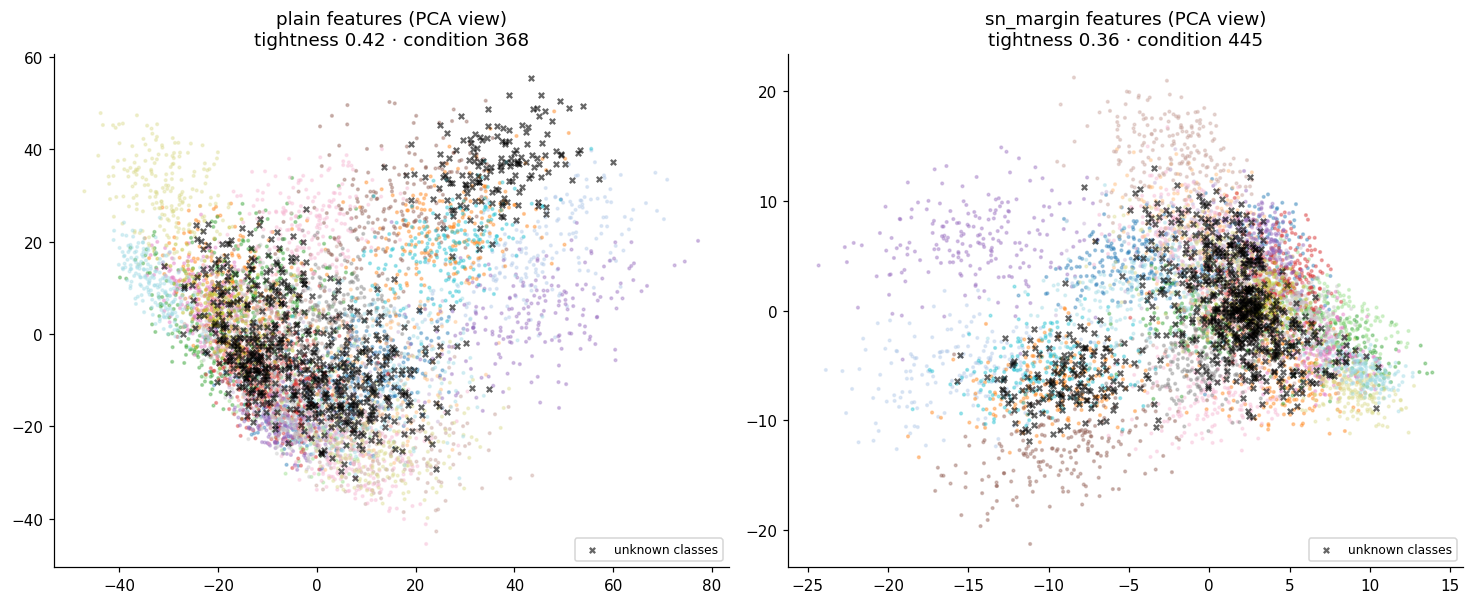

In [9]:
# --- What each feature space offers the detector -----------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.6))
for ax, kind in zip(axes, ("plain", "sn_margin")):
    Ztr, _ = features(MODELS[kind], X_train)
    Znear, _ = features(MODELS[kind], X_near)
    p = PCA(n_components=2).fit(Ztr)
    t2, n2 = p.transform(Ztr), p.transform(Znear)
    ax.scatter(*t2.T, c=y_train, cmap="tab20", s=3, alpha=0.35)
    ax.scatter(*n2.T, marker="x", c="black", s=12, alpha=0.6, label="unknown classes")
    mu = np.stack([Ztr[y_train == c].mean(0) for c in range(C)])
    cov = LedoitWolf().fit(Ztr - mu[y_train]).covariance_
    ev = np.linalg.eigvalsh(cov)
    intra = np.mean([np.linalg.norm(Ztr[y_train == c] - mu[c], axis=1).mean()
                     for c in range(C)])
    inter = np.linalg.norm(mu[:, None] - mu[None], axis=-1)[np.triu_indices(C, 1)].mean()
    ax.set_title(f"{kind} features (PCA view)\n"
                 f"tightness {intra / inter:.2f} · condition {ev[-1] / ev[0]:,.0f}")
    ax.legend(loc="lower right", fontsize=8); ax.grid(False)
plt.tight_layout(); plt.show()

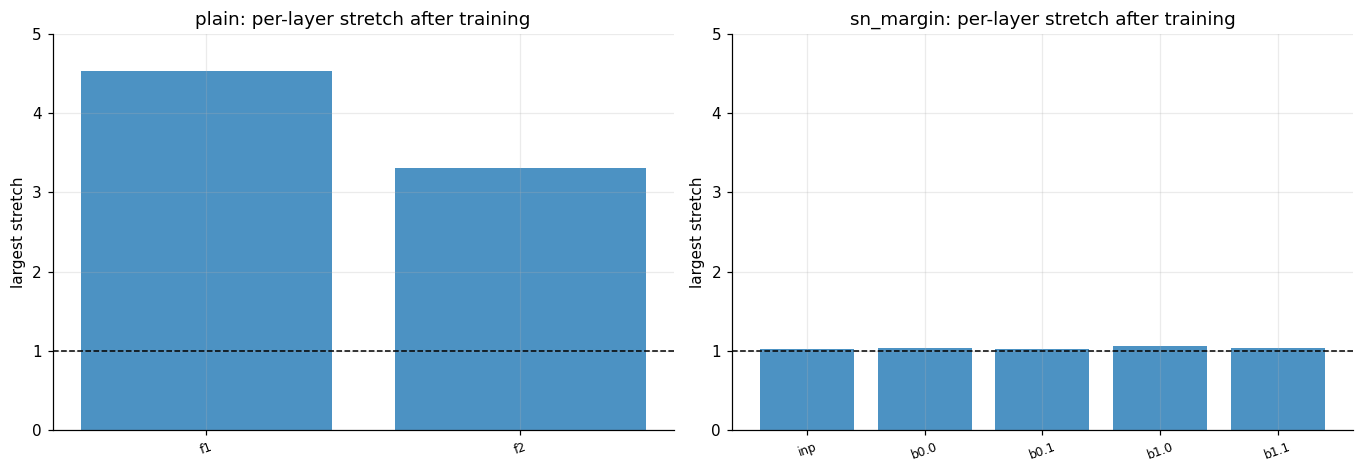

Left: ordinary training let each layer's stretch drift to 3-5, and stretches
multiply through depth. Right: every constrained layer sits at ~1 (a hair above:
power iteration is an estimate). The section-4 promise, measured on the exact
encoders this notebook deploys.


In [10]:
# --- What training did to each layer's stretch, on the deployed encoders -----------
def layer_stretches(m):
    out = []
    for name, mod in m.named_modules():
        if isinstance(mod, nn.Linear) and "head" not in name:
            with torch.no_grad():
                out.append((name, torch.linalg.svdvals(mod.weight).max().item()))
    return out

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
for ax, kind in zip(axes, ("plain", "sn_margin")):
    names, tops = zip(*layer_stretches(MODELS[kind]))
    ax.bar(range(len(tops)), tops, color="tab:blue", alpha=0.8)
    ax.axhline(1.0, color="black", lw=1, ls="--")
    ax.set_xticks(range(len(tops)))
    ax.set_xticklabels([n.replace("blocks.", "b") for n in names], rotation=20, fontsize=8)
    ax.set_ylabel("largest stretch")
    ax.set_title(f"{kind}: per-layer stretch after training")
    ax.set_ylim(0, 5)
plt.tight_layout(); plt.show()
print("Left: ordinary training let each layer's stretch drift to 3-5, and stretches")
print("multiply through depth. Right: every constrained layer sits at ~1 (a hair above:")
print("power iteration is an estimate). The section-4 promise, measured on the exact")
print("encoders this notebook deploys.")

Same data, same capacity, same inference cost — and sn_margin delivers higher accuracy,
tighter clusters, and better near detection with a *third* of the seed-to-seed spread
(far detection sits at the ceiling for both, .996 vs .997 — noise). The spread is the
quiet number worth the most: retrain the sn_margin encoder five times and you get
essentially the same detector five times, while the plain encoder's detection quality
wanders between retrains. The printed condition numbers say it plainest: the covariance
the Gaussian fit must invert averages two thousand for the plain encoder with a spread of
over a thousand — a seed lottery — while sn_margin pins it near 450 with almost no spread
at all. (The PCA figure above shows seed 0, where the plain encoder happened to draw a
lucky ticket; the spread is the point.) The two training changes cost nothing at
inference. What they buy is a feature space you can rely on.

To *see* the two changes work — not just read their scoreboard — go back to two
dimensions, where a feature space fits on the page. We train three tiny encoders with
2-D features on the toy problem and draw what each does to a regular grid laid over
input space. (The companion notebook *Spectral Normalization, Drawn* derives every bound
behind these pictures.)

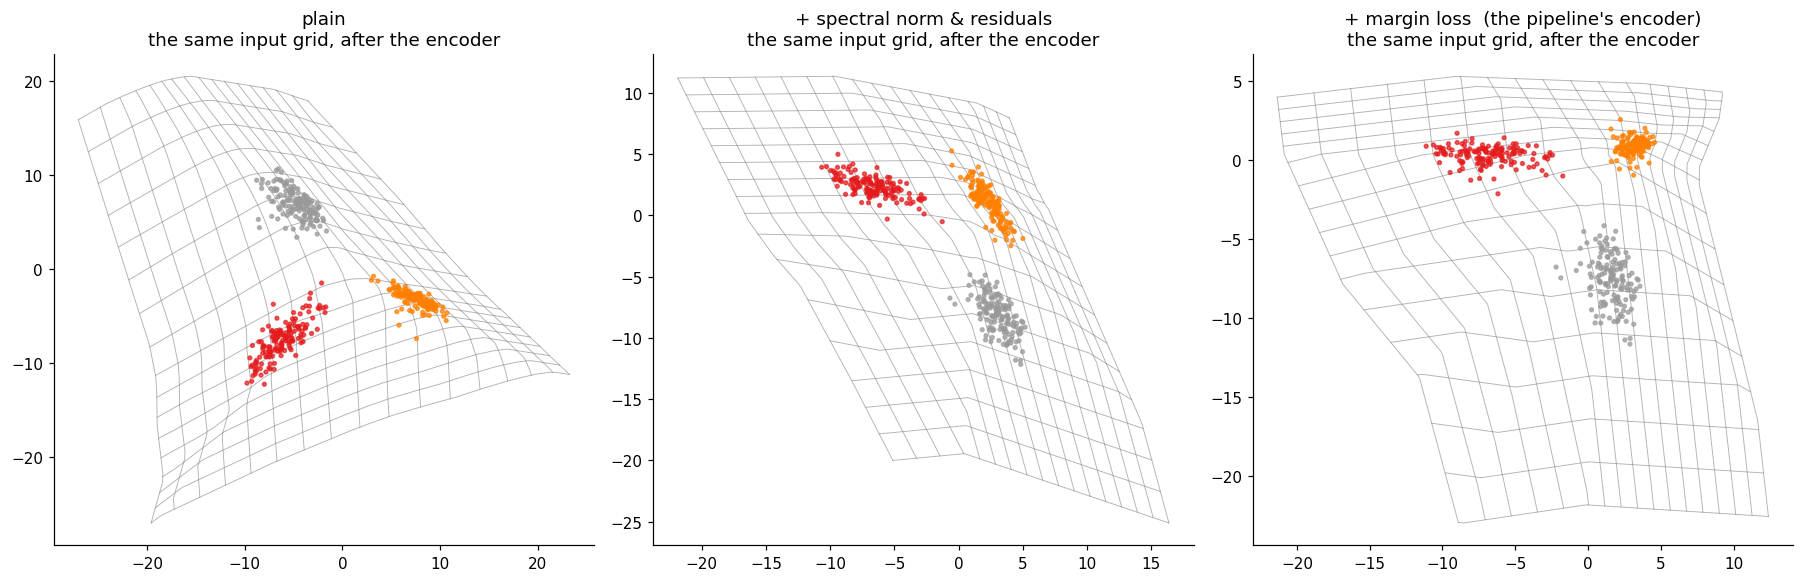

In [11]:
# --- The two changes, watched one at a time in 2-D ---------------------------------
X2 = X_toy.astype(np.float32)
y2t = torch.from_numpy(y_toy)

class Toy2D(nn.Module):
    def __init__(self, constrained):
        super().__init__()
        SN = nn.utils.parametrizations.spectral_norm if constrained else (lambda m: m)
        self.constrained = constrained
        if constrained:
            self.inp = SN(nn.Linear(2, 2))
            self.blocks = nn.ModuleList([
                nn.ModuleList([SN(nn.Linear(2, 2)), SN(nn.Linear(2, 2))])
                for _ in range(3)])
        else:
            self.f1, self.f2 = nn.Linear(2, 32), nn.Linear(32, 2)
        self.head = nn.Linear(2, 3)

    def features(self, x):                 # linear read-out keeps the geometry visible
        if self.constrained:
            h = self.inp(x)
            for a, b in self.blocks:
                h = h + 0.95 * b(F.relu(a(h)))
            return h
        return self.f2(F.relu(self.f1(x)))

    def forward(self, x):
        z = self.features(x)
        return z, self.head(z)


def train_toy(constrained, use_margin, epochs=300):
    torch.manual_seed(0)
    m = Toy2D(constrained)
    opt = torch.optim.Adam(m.parameters(), lr=1e-3)
    Xt = torch.from_numpy(X2)
    for _ in range(epochs):
        perm = torch.randperm(len(Xt))
        for i in range(0, len(Xt), 128):
            z, logits = m(Xt[perm[i:i + 128]])
            loss = F.cross_entropy(logits, y2t[perm[i:i + 128]])
            if use_margin:
                loss = loss + margin_loss(z, y2t[perm[i:i + 128]])
            opt.zero_grad(); loss.backward(); opt.step()
    m.eval()
    return m


grid_lines = []
for v in np.linspace(-8, 8, 17):
    t = np.linspace(-8, 8, 200)
    grid_lines.append(np.stack([np.full_like(t, v), t], 1))
    grid_lines.append(np.stack([t, np.full_like(t, v)], 1))

fig, axes = plt.subplots(1, 3, figsize=(16.5, 5.4))
for ax, (constrained, use_margin, label) in zip(
        axes, [(False, False, "plain"),
               (True, False, "+ spectral norm & residuals"),
               (True, True, "+ margin loss  (the pipeline's encoder)")]):
    m = train_toy(constrained, use_margin)
    with torch.no_grad():
        for line in grid_lines:
            L = m.features(torch.from_numpy(line.astype(np.float32))).numpy()
            ax.plot(*L.T, c="gray", lw=0.6, alpha=0.6)
        Z2 = m.features(torch.from_numpy(X2)).numpy()
    ax.scatter(*Z2.T, c=y_toy, cmap="Set1", s=6, alpha=0.7, zorder=5)
    ax.set_title(f"{label}\nthe same input grid, after the encoder")
    ax.grid(False)
plt.tight_layout(); plt.show()

Left to right, one change at a time. The **plain** encoder deforms the grid unevenly —
cells tiny in one region, enormous in another — so a step in input space means different
things in different places. Adding **spectral norm and residuals** makes the cells
roughly uniform: distance now means the same thing everywhere. The honest map. Adding
the **margin loss** keeps that map and pulls the classes into tighter knots on top of
it — watch the orange cluster — the shape a Gaussian fits best. Honest map first, tight
clusters second: the entire encoder recipe, in three pictures.

## 5. The fence: drawn by data, not by formula

The score is a distance. Somewhere along it we must place the fence: nearer, classify;
farther, reject.

The textbook offers a formula. If features were exactly Gaussian, squared distance would
follow a chi-square law, and the 95% fence could be read from a table. Resist it, for two
reasons. First, you cannot sanity-check the formula by intuition up here: in 64
dimensions a perfectly *normal* point sits about eight "sigmas" from its own center —
each of the 64 coordinates contributes roughly one squared sigma, the total is about 64,
and its square root is 8 — so if the fence lands in the wrong place, no mental picture
will warn you. Second, it does
land in the wrong place: real features are always heavier-tailed than the Gaussian
assumption, so the formula silently throws away good inputs.

The data offers something better. Take held-out known-good inputs the fit never saw,
score them, and place the fence where 95% of them pass. Why does that promise hold for
*future* inputs, not just these? Because a fresh known-good input is statistically
identical to the held-out ones — before you look at it, nothing distinguishes it from
them. Line up all their scores: the newcomer's position in that lineup is uniformly
random, so the chance it lands in the bottom 5% is, on average, 5%. That is the entire
proof, and no Gaussian assumption appears anywhere in it. (The rank trick has a name —
conformal prediction — and with 3,000 held-out points the plain quantile below delivers
it to within a hair:)

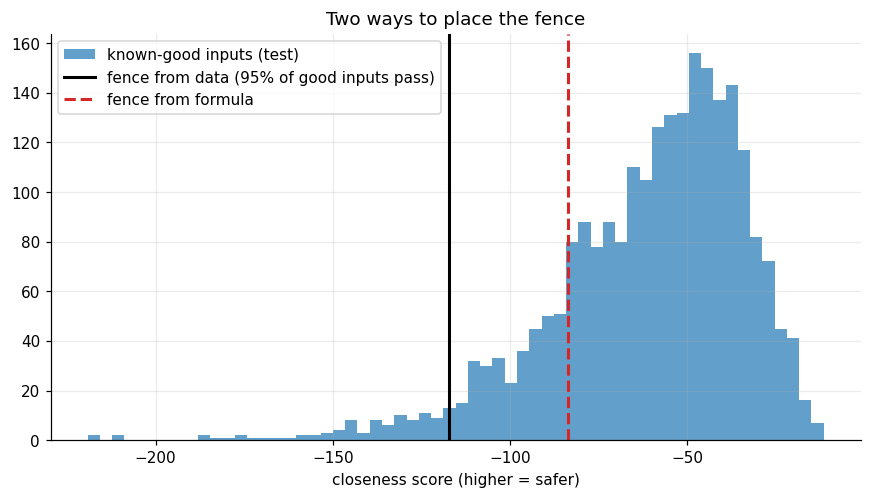

formula fence: keeps 82.1% of good inputs (promised 95%)
data fence:    keeps 96.1% of good inputs (promised 95%)


In [12]:
model = MODELS["sn_margin"]
Ztr, _ = features(model, X_train)
score = fit_maha(Ztr, y_train)

s_val = score(features(model, X_val)[0])          # held-out: sets the fence
s_test = score(features(model, X_test)[0])        # never touched: checks the promise

fence_data = np.quantile(s_val, 0.05)             # 95% of held-out ID passes
fence_formula = -chi2.ppf(0.95, df=64)            # what the chi-square table says

fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.hist(s_test, bins=60, alpha=0.7, color="tab:blue", label="known-good inputs (test)")
ax.axvline(fence_data, color="black", lw=2,
           label="fence from data (95% of good inputs pass)")
ax.axvline(fence_formula, color="tab:red", lw=2, ls="--", label="fence from formula")
ax.set_xlabel("closeness score (higher = safer)")
ax.set_title("Two ways to place the fence")
ax.legend()
plt.show()

print(f"formula fence: keeps {np.mean(s_test >= fence_formula):5.1%} of good inputs "
      f"(promised 95%)")
print(f"data fence:    keeps {np.mean(s_test >= fence_data):5.1%} of good inputs "
      f"(promised 95%)")

The formula breaks its promise; the data keeps it. This is the one rule of thresholds
worth memorizing: **the fence is a quantile of your own data, never a number from a
table.**

And the 95% itself is a dial, not a law. It states the price you accept in good inputs;
what each price buys in caught novelty is then a measurement. Three settings of the same
dial, worked out:

In [13]:
# --- Choosing the budget: the same fence at three prices ---------------------------
s_near = score(features(model, X_near)[0])
s_far = score(features(model, X_far)[0])
print(f"{'price paid (good inputs lost)':>30s} {'good kept':>10s} "
      f"{'similar novelty caught':>23s} {'remote novelty caught':>22s}")
for alpha in (0.01, 0.05, 0.10):
    f_ = np.quantile(s_val, alpha)
    print(f"{alpha:>29.0%} {np.mean(s_test >= f_):>10.1%} "
          f"{np.mean(s_near < f_):>23.1%} {np.mean(s_far < f_):>22.1%}")
print()
print("The left column is promised; the right two are measured. Pick the row your")
print("product can live with -- and notice how much similar-novelty catch rate one")
print("extra percent of good inputs buys.")

 price paid (good inputs lost)  good kept  similar novelty caught  remote novelty caught
                           1%      99.3%                   39.5%                  94.2%
                           5%      96.1%                   57.9%                  97.1%
                          10%      90.2%                   66.9%                  98.9%

The left column is promised; the right two are measured. Pick the row your
product can live with -- and notice how much similar-novelty catch rate one
extra percent of good inputs buys.


## 6. The 60 outliers: a measuring stick, not fuel

You have 60 collected outlier examples. They answer exactly one question honestly: *of
the novelty seen so far, how much does this fence catch?* Count the catches and wrap the
count in a binomial confidence interval — at $n = 60$ that interval spans ten or more
percentage points, and reporting the bare percentage would be pretending to know more
than you do.

What the 60 must never become is training data. They describe the few kinds of novelty
you happened to meet; a detector fitted to them aces those kinds and fails the next one —
a claim this notebook does not ask you to take on faith, because a few cells below we
run that trap on this very pipeline and watch it spring. (Part 1 of the series first measured
it at full strength: 0.99 on seen kinds, 0.55 — a coin flip — on unseen.)

In [14]:
# Your situation, simulated: 60 outliers collected from just 3 of the 8 unknown classes.
X_60 = np.vstack([sample_class(means_near[i], scales[C + i], 20) for i in (0, 1)]
                 + [sample_class(means_far[0], scales[C + 5], 20)])
X_unseen = np.vstack([sample_class(means_near[i], scales[C + i], 150) for i in (2, 3, 4)]
                     + [sample_class(means_far[i], scales[C + 5 + i], 150) for i in (1, 2)])

def wilson(k, n, z=1.96):
    p = k / n
    center = (p + z**2 / (2 * n)) / (1 + z**2 / n)
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / (1 + z**2 / n)
    return center - half, center + half

caught = int((score(features(model, X_60)[0]) < fence_data).sum())
lo, hi = wilson(caught, 60)
print(f"of the 60 collected outliers, the fence catches {caught} "
      f"({caught / 60:.0%};  95% interval {lo:.0%} to {hi:.0%})")
print(f"on outlier classes never collected, it catches "
      f"{np.mean(score(features(model, X_unseen)[0]) < fence_data):.0%}")
print()
print("Report the interval. The point estimate alone overstates what 60 examples know.")

of the 60 collected outliers, the fence catches 49 (82%;  95% interval 70% to 89%)


on outlier classes never collected, it catches 63%

Report the interval. The point estimate alone overstates what 60 examples know.


It is worth watching the mistake fail, not just reading about it. Below, a detector
**trained** on the 60 — known-good features labeled 0, the 60 labeled 1 — against the
pipeline's fence, which never met an outlier. Both are judged twice: on fresh outliers of
the kinds the 60 contained, and on the kinds they did not.

In [15]:
# --- The mistake, demonstrated -----------------------------------------------------
Z_val60 = np.vstack([features(model, X_val)[0], features(model, X_60)[0]])
sup = LogisticRegression(max_iter=2000, class_weight="balanced").fit(
    Z_val60, np.r_[np.zeros(len(X_val)), np.ones(60)])
X_seen_fresh = np.vstack([sample_class(means_near[i], scales[C + i], 150) for i in (0, 1)]
                         + [sample_class(means_far[0], scales[C + 5], 150)])

def sup_score(X):
    return -sup.decision_function(features(model, X)[0])   # higher = looks known-good

s_id_sup = sup_score(X_test)
print("detector TRAINED on the 60:")
print(f"  vs fresh outliers of the kinds it saw:  AUROC "
      f"{auroc(s_id_sup, sup_score(X_seen_fresh)):.2f}")
print(f"  vs outlier kinds it never saw:          AUROC "
      f"{auroc(s_id_sup, sup_score(X_unseen)):.2f}")
print("the pipeline's score, which never touched the 60:")
print(f"  vs the same seen kinds:                 AUROC "
      f"{auroc(s_test, score(features(model, X_seen_fresh)[0])):.2f}")
print(f"  vs the same unseen kinds:               AUROC "
      f"{auroc(s_test, score(features(model, X_unseen)[0])):.2f}")
print()
print("Perfect on what it memorized, well behind the untrained fence on what it did")
print("not. Sixty examples describe the novelty you have met -- never the novelty")
print("that is coming.")

detector TRAINED on the 60:
  vs fresh outliers of the kinds it saw:  AUROC 1.00
  vs outlier kinds it never saw:          AUROC 0.73
the pipeline's score, which never touched the 60:
  vs the same seen kinds:                 AUROC 0.98


  vs the same unseen kinds:               AUROC 0.87

Perfect on what it memorized, well behind the untrained fence on what it did
not. Sixty examples describe the novelty you have met -- never the novelty
that is coming.


## 7. The whole pipeline, assembled

Everything above, as one object. Notice how little there is: an encoder, thirty means,
one covariance, one quantile.

=== final report ===
known inputs kept:        96.1%   (promised: 95%)
accuracy on kept inputs:  87.5%
near-unknowns rejected:   57.9%
far-unknowns rejected:    97.1%


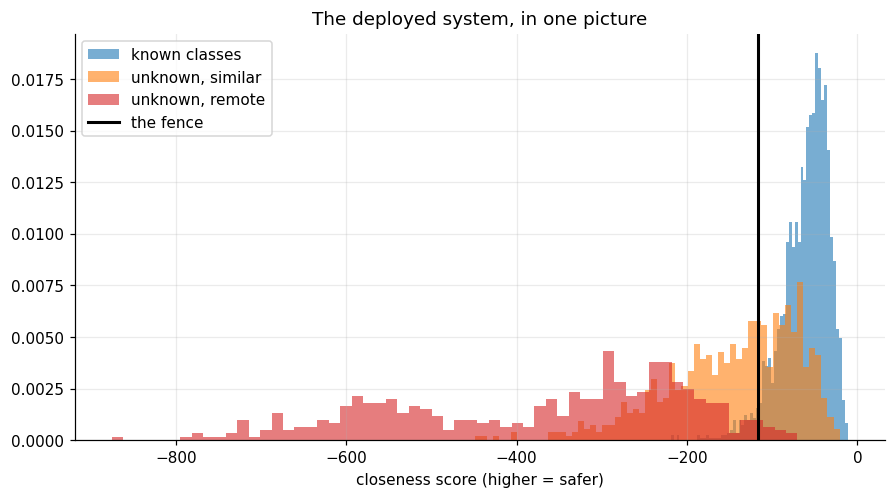

In [16]:
class OpenSetClassifier:
    """Classify among known classes, or reject as unknown.

    fit():     class centers + pooled shrunk covariance on training features,
               fence at the alpha-quantile of held-out known-good scores.
    predict(): the classifier's label, or REJECT when the score falls past the fence.
    """
    REJECT = -1

    def __init__(self, model, alpha=0.05):
        self.model, self.alpha = model, alpha

    def _feats(self, X):
        with torch.no_grad():
            z, logits = self.model(torch.from_numpy(X))
        return z.numpy(), logits.numpy()

    def fit(self, X_train, y_train, X_heldout):
        Z, _ = self._feats(X_train)
        self.mu_ = np.stack([Z[y_train == c].mean(0) for c in range(C)])
        self.prec_ = LedoitWolf().fit(Z - self.mu_[y_train]).precision_
        self.fence_ = np.quantile(self.score(X_heldout), self.alpha)
        return self

    def score(self, X):
        Z, _ = self._feats(X)
        d2 = np.stack([np.einsum("nd,dk,nk->n", Z - m, self.prec_, Z - m)
                       for m in self.mu_], 1)
        return -d2.min(1)

    def predict(self, X):
        _, logits = self._feats(X)
        labels = logits.argmax(1)
        labels[self.score(X) < self.fence_] = self.REJECT
        return labels


osc = OpenSetClassifier(MODELS["sn_margin"]).fit(X_train, y_train, X_val)

pred = osc.predict(X_test)
kept = pred != OpenSetClassifier.REJECT
print("=== final report ===")
print(f"known inputs kept:        {kept.mean():5.1%}   (promised: 95%)")
print(f"accuracy on kept inputs:  {(pred[kept] == y_test[kept]).mean():5.1%}")
print(f"near-unknowns rejected:   {(osc.predict(X_near) == -1).mean():5.1%}")
print(f"far-unknowns rejected:    {(osc.predict(X_far) == -1).mean():5.1%}")

fig, ax = plt.subplots(figsize=(9.5, 4.8))
for X, label, color in [(X_test, "known classes", "tab:blue"),
                        (X_near, "unknown, similar", "tab:orange"),
                        (X_far, "unknown, remote", "tab:red")]:
    ax.hist(osc.score(X), bins=60, alpha=0.6, density=True, label=label, color=color)
ax.axvline(osc.fence_, color="black", lw=2, label="the fence")
ax.set_xlabel("closeness score (higher = safer)")
ax.set_title("The deployed system, in one picture")
ax.legend()
plt.show()

One picture, one number each: known inputs pass the fence at the promised rate and keep
their accuracy; remote novelty is caught almost entirely; similar novelty — the honest
hard case — is caught at a rate you now *measure* instead of guess.

Numbers summarize; examples convince. First, three individual inputs traced through
every stage of the pipeline. Then a mixed batch, the way inference actually arrives.

In [17]:
# --- Three inputs, traced end to end -----------------------------------------------
def trace(name, x, truth=""):
    z = osc._feats(x[None])[0][0]
    d2 = np.array([np.einsum("d,dk,k->", z - m_, osc.prec_, z - m_) for m_ in osc.mu_])
    top = np.argsort(d2)[:3]
    s = -d2.min()
    verdict = (f"ACCEPT, label class {top[0]}" if s >= osc.fence_
               else "REJECT as unknown")
    print(f"{name} {truth}")
    print(f"  nearest classes (squared distance): "
          + ",  ".join(f"class {c}: {d2[c]:,.0f}" for c in top))
    print(f"  score {s:,.0f}   fence {osc.fence_:,.0f}   ->  {verdict}\n")

trace("A known-good input.", X_test[5], f"(true class: {y_test[5]})")
trace("An unknown of a similar kind.", X_near[7])
trace("An unknown of a remote kind.", X_far[3])

A known-good input. (true class: 0)
  nearest classes (squared distance): class 0: 46,  class 1: 95,  class 14: 100
  score -46   fence -117   ->  ACCEPT, label class 0

An unknown of a similar kind. 
  nearest classes (squared distance): class 28: 241,  class 21: 255,  class 7: 257
  score -241   fence -117   ->  REJECT as unknown

An unknown of a remote kind. 
  nearest classes (squared distance): class 1: 406,  class 5: 416,  class 14: 422
  score -406   fence -117   ->  REJECT as unknown



In [18]:
# --- A day in production: a mixed batch of twelve ----------------------------------
batch = np.vstack([X_test[:6], X_near[:4], X_far[:2]])
truth = ["known"] * 6 + ["unknown (similar)"] * 4 + ["unknown (remote)"] * 2
pred = osc.predict(batch)
scores = osc.score(batch)
print(f"{'#':>2s}  {'truth':18s} {'score':>9s}  {'decision':16s} ok?")
print("-" * 55)
n_ok = 0
for i, (t, p, s) in enumerate(zip(truth, pred, scores)):
    dec = "REJECT" if p == -1 else f"class {p}"
    if t == "known":
        good = (p == y_test[i])
    else:
        good = (p == -1)
    n_ok += good
    print(f"{i:>2d}  {t:18s} {s:>9,.0f}  {dec:16s} {'yes' if good else 'NO'}")
print(f"\n{n_ok}/12 handled correctly -- and the misses are worth reading closely,")
print("because they come in two kinds with two different owners. Known inputs given the")
print("wrong label are ordinary classification errors (the accuracy number's job, not")
print("the fence's -- their scores sit well inside the fence). A similar unknown that")
print("slips past is the fence's miss, from exactly the zone whose catch rate section 6")
print("measured with an interval. This table is what those percentages look like, one")
print("input at a time.")

 #  truth                  score  decision         ok?
-------------------------------------------------------
 0  known                    -40  class 0          yes
 1  known                    -78  class 28         NO
 2  known                    -72  class 0          yes
 3  known                    -59  class 12         NO
 4  known                    -46  class 0          yes
 5  known                    -46  class 0          yes
 6  unknown (similar)        -96  class 11         NO
 7  unknown (similar)       -197  REJECT           yes
 8  unknown (similar)       -128  REJECT           yes
 9  unknown (similar)       -180  REJECT           yes
10  unknown (remote)        -361  REJECT           yes
11  unknown (remote)        -249  REJECT           yes

9/12 handled correctly -- and the misses are worth reading closely,
because they come in two kinds with two different owners. Known inputs given the
wrong label are ordinary classification errors (the accuracy number's job, not
the

## 8. What this trades away, and taking it to your data

The full series squeezed a few more points of near-OOD detection out of score
combinations (adding RMDS, kNN, and NECO to the Mahalanobis core) and seed ensembles.
This pipeline trades those points for a system with one moving part. For most
deployments that is the right trade; Part 4 holds the upgrade path when it stops being
enough.

On your real data, in order:

1. **Retrain your classifier** with the margin loss and spectral normalization. Keep the
   retrain only if accuracy holds *and* detection improves *and* the two diagnostics
   (cluster tightness, covariance condition) do not degrade — measured over 3–5 seeds.
2. **Fit the detector**: class means + Ledoit–Wolf pooled covariance on training
   features. Twenty lines; no tuning.
3. **Place the fence** so that 95% of held-out known-good inputs pass it — with the
   higher-is-safer score coded here, that is the 5% quantile (`alpha=0.05`). Never the
   chi-square table.
4. **Measure with the 60**: catches, Wilson interval, sliced by outlier type if you know
   the types. Report the interval.
5. **Refit and re-fence after every retrain** — the detector is a function of the feature
   space, and it goes stale the moment the encoder changes.
6. When you want the extra points: Part 4's conformal combination (RMDS + kNN + NECO) sits
   on the same fitted objects.

### The series, for the deeper why

- Part 1 — every score derived from first principles; the conformal machinery; the
  60-outlier protocol.
- Part 2 — why this encoder wins and how three famous training losses fail.
- Part 3 — why "native" open-set models lose to this read-out on their own features.
- Part 4 — CIDER under the microscope; the modern post-hoc scores and the combination
  upgrade.
- *Spectral Normalization, Drawn* — the encoder's constraint, derived bound by bound.

**References.** Lee et al. (NeurIPS 2018) — Mahalanobis on deep features
[arXiv:1807.03888](https://arxiv.org/abs/1807.03888) · Liu et al. (NeurIPS 2020) —
spectral normalization for distance-aware features
[arXiv:2006.10108](https://arxiv.org/abs/2006.10108) · Zhou et al. (EMNLP 2021) — margin
loss for OOD-aware representations [arXiv:2104.08812](https://arxiv.org/abs/2104.08812) ·
Vovk et al. — *Algorithmic Learning in a Random World* (conformal prediction) · Ledoit &
Wolf (2004) — covariance shrinkage.